In [16]:
import matplotlib.pyplot as plt
import zarr
import pandas
import cv2
import numpy as np
from pathlib import Path
from skimage import filters



root = Path("/Volumes/data/Sasaki/MTsingleBeads")
#root = Path("/mnt/NAS-Ebanaru/sasaki/MTsingleBeads")

folder = root / "control" / "MTs8uM" / "20260624" / "MTs8uM"

MTs_file = folder / "GFP.zarr"

MTs = zarr.open_array(MTs_file, mode='r')

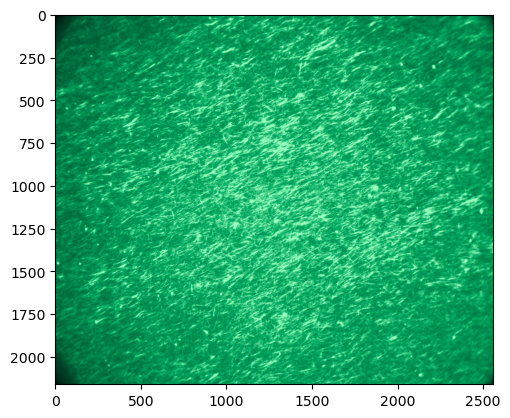

In [20]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

MTs_max_factor = 0.5

gfp_base = mcolors.to_rgb("#00A960")  # (0.0, 0.663, 0.376)

cud_gfp_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_gfp",
    [
        (0.0, (0.0, 0.0, 0.0, 1.0)),              # 輝度0: 完全透明な黒
        (0.7, (gfp_base[0], gfp_base[1], gfp_base[2], 1.0)), # 輝度70%: 純粋なCUD緑（半透明）
        (1.0, (0.6, 1.0, 0.75, 1.0))              # 輝度100%: 芯が光るエメラルドホワイト（不透明）
    ]
)
# 図を2つ並べて表示する場合
fig, ax = plt.subplots()
# 最初のプロット：MTs
ax.imshow(MTs[0], cmap=cud_gfp_cmap, vmin=MTs[0].min(), vmax = MTs[0].max()*MTs_max_factor)

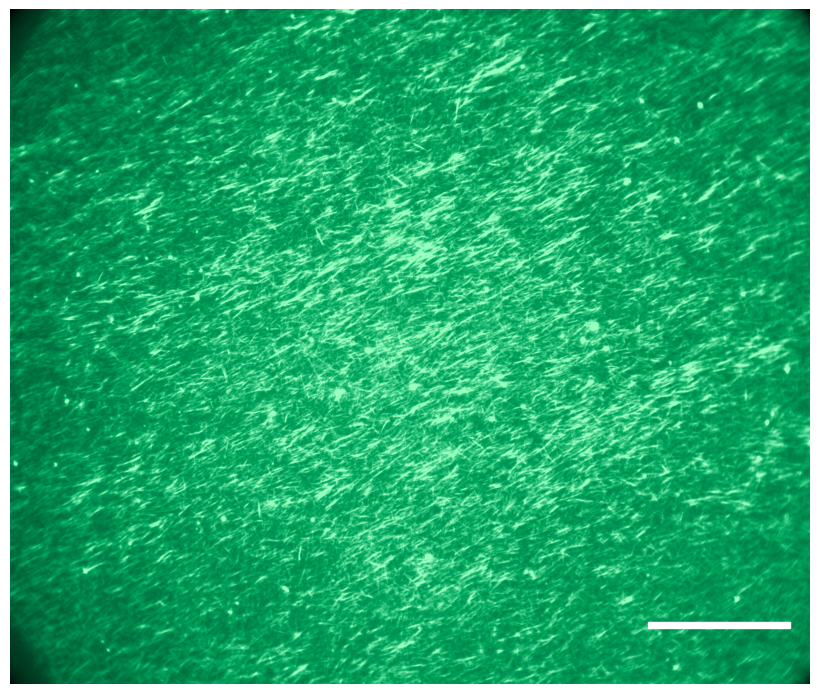

In [21]:
from matplotlib.animation import FuncAnimation
import numpy as np
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt # 必要に応じて

scale = 0.11
n_frames = MTs.shape[0]

# ==========================================
# 修正ポイント1: 画像の縦横比（ピクセル数）に合わせてFigureを作成
# ==========================================
height, width = MTs[0].shape
fig, ax = plt.subplots(figsize=(8, 8 * (height / width)))

# 画像
im1 = ax.imshow(MTs[0], cmap=cud_gfp_cmap, animated=True, vmin=MTs[0].min(), vmax=MTs[0].max()*MTs_max_factor)

# ==========================================
# 修正ポイント2: 軸と余白の完全な無効化（固定）
# ==========================================
ax.axis('off')
ax.set_position([0, 0, 1, 1]) # AxesをFigure全体に限界まで広げる
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

fontprops = fm.FontProperties(size=24)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/scale,
                           label='',
                           loc=4,
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
ax.add_artist(size_bar)

def update_frame(frame):
    im1.set_array(MTs[frame])

    return im1,

anim = FuncAnimation(fig, update_frame,
                     frames=n_frames,
                     interval=100,
                     blit=True, repeat=True)


In [22]:
#anim.save("/Users/sasakinozomu/Desktop/anim.mp4", savefig_kwargs={"pad_inches": 0, "bbox_inches": "tight"})
anim.save(str(folder / "anim.mp4"), savefig_kwargs={"pad_inches": 0, "bbox_inches": "tight"})

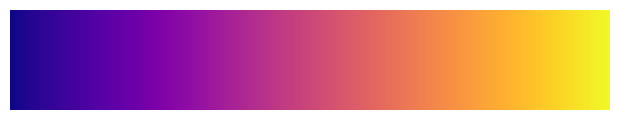

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 動画内での時間の最小値と最大値（例: 0秒から100秒）
vmin = 0
vmax = 100

fig, ax = plt.subplots(figsize=(6, 1))  # 横長の図を作成
fig.subplots_adjust(bottom=0.5)

# カラーマップと正規化
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# カラーバーを作成（水平方向）
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=ax, orientation='horizontal')
cbar.set_label('Time (s)') # 単位に合わせてラベルを変更してください

plt.axis("off")
plt.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

#plt.title('Time Colorbar')
plt.show()

# 必要であれば保存します
fig.savefig('/Users/sasakinozomu/Desktop/colorbar.pdf', bbox_inches='tight')
